## Rank(k)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

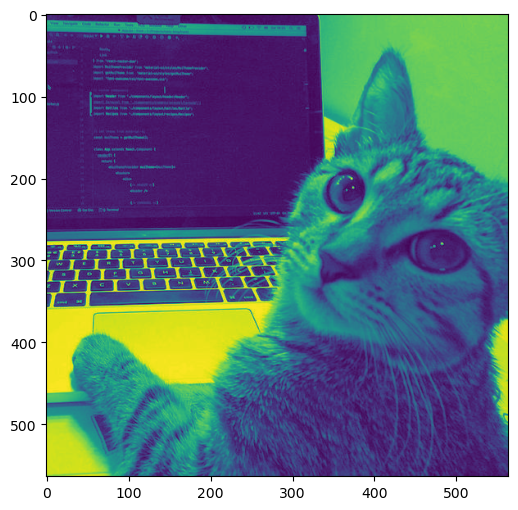

In [85]:
# Load image
img = Image.open("../Kitty.jpeg")

img_gray = img.convert("L") # convert image grayscale

plt.figure(figsize=(10, 6))
plt.imshow(img_gray)
plt.show()

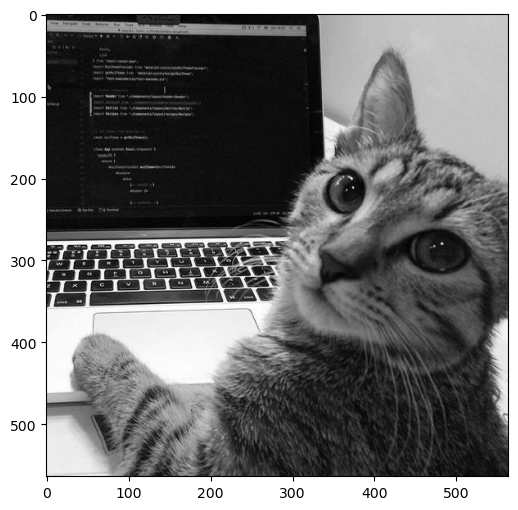

In [71]:
# Convert image to matrix using numpy
img_mat = np.array(img_gray, float) # Extracts only the gray scale values
img_mat.shape = (img_gray.size[1], img_gray.size[0]) # Reshape into 2D
img_mat = np.array(img_mat)

plt.figure(figsize=(10, 6))
plt.imshow(img_mat, cmap='gray')
plt.show()

In [72]:
# performing Singular Value Decomposition
U, S, VT = np.linalg.svd(img_mat, full_matrices=False)

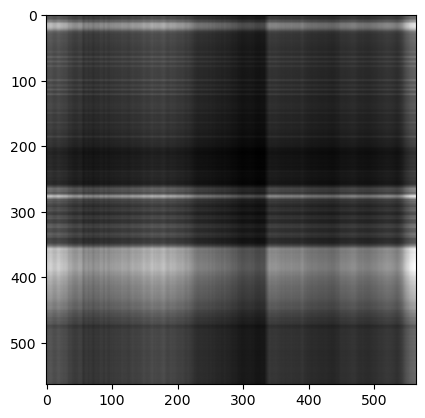

In [76]:
# Rank 1
U1 = U[:, :1]
S1 = S[:1]
VT1 = VT[:1, :]
reconstructing = (U1 * S1) @ VT1
plt.imshow(reconstructing, cmap='gray')
plt.show()

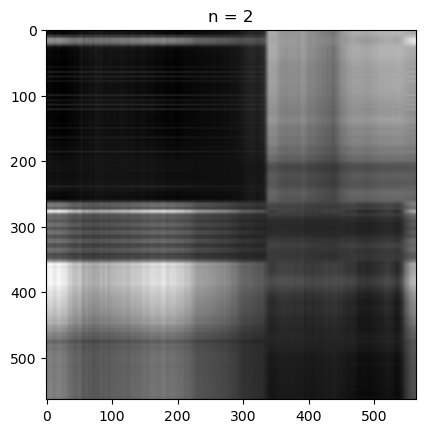

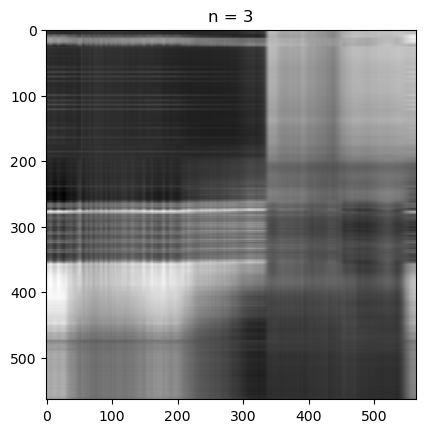

In [77]:
# Rank 2 and Rank 3 approximations
for k in range(2, 4):
    reconstructing = (U[:, :k] * S[:k]) @ VT[:k, :]
    title = f"n = {k}"
    plt.imshow(reconstructing, cmap='gray')
    plt.title(title)
    plt.show()

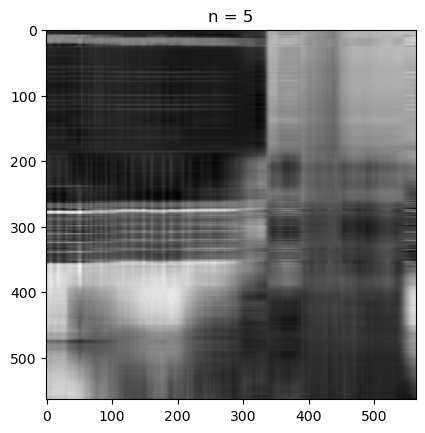

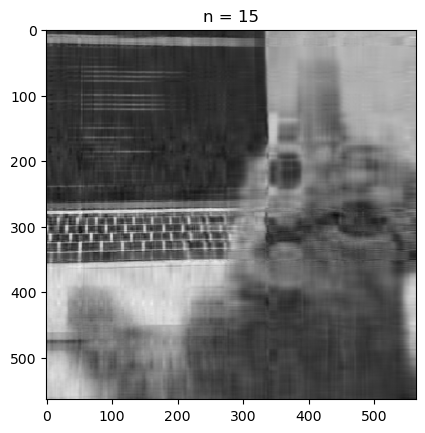

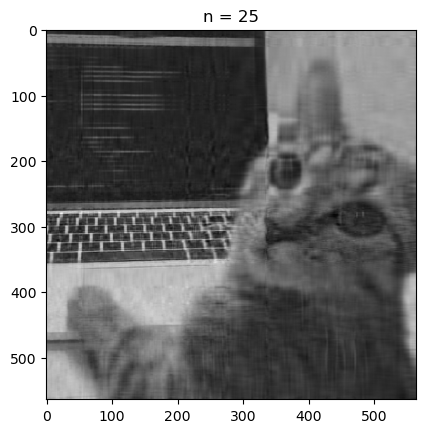

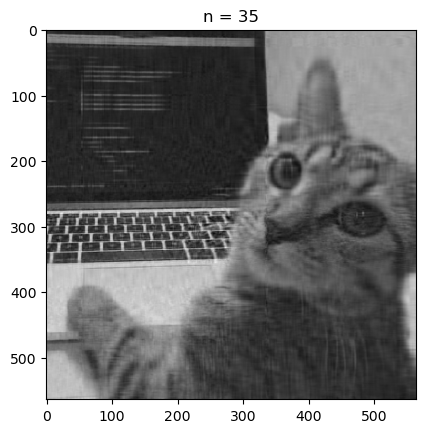

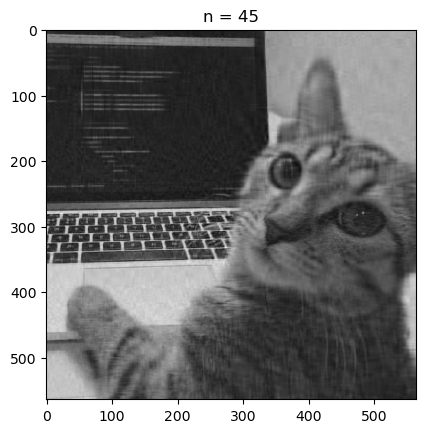

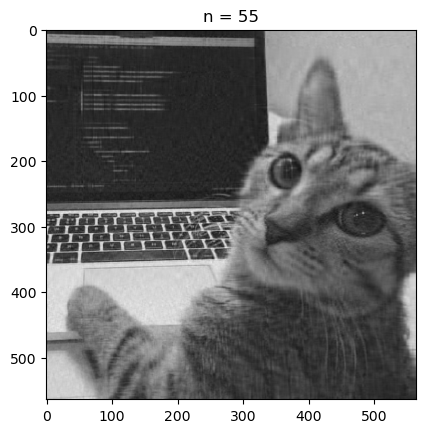

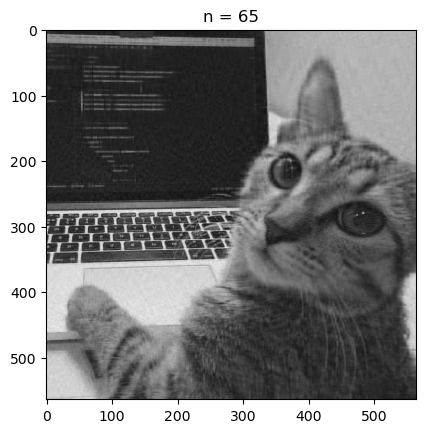

In [79]:
# Progressive refinement as the rank increases
for k in range(5, 75, 10):
    reconstructing = (U[:, :k] * S[:k]) @ VT[:k, :]
    title = f"n = {k}"
    plt.imshow(reconstructing, cmap='gray')
    plt.title(title)
    plt.show()

In [84]:
# Evaluation
def compression_stats(k):
    original = m * n
    compressed = k * (m + n + 1)
    ratio = original / compressed
    return original, compressed, ratio

In [83]:
k = 50
m, n = img_mat.shape
orig, comp, ratio = compression_stats(k)

print(f"Original size: {orig}")
print(f"Compressed size: {comp}")
print(f"Compression ratio: {ratio:.2f}x")

Original size: 318096
Compressed size: 56450
Compression ratio: 5.64x
